Loading data...
Total samples after loading: 343889
Class distribution (binary):
label
1    275465
0     68424
Name: count, dtype: int64

Attack type distribution:
attack_type
Probe         98129
DDoS          73529
benign        68424
DoS           53616
DDoS          48413
BFA            1405
Web-Attack      192
BOTNET          164
U2R              17
Name: count, dtype: int64

Preprocessing...
Dropping 11 constant features.

Splitting data...
Train: 206333  Val: 68778  Test: 68778

Training binary classifiers...

Grid search for LogisticRegression ...
Fitting 1 folds for each of 3 candidates, totalling 3 fits
Best params LogisticRegression: {'clf__C': 0.1, 'clf__penalty': 'l2'}

Grid search for RandomForest ...
Fitting 1 folds for each of 6 candidates, totalling 6 fits
Best params RandomForest: {'clf__max_depth': None, 'clf__n_estimators': 100}

Grid search for GradientBoosting ...
Fitting 1 folds for each of 8 candidates, totalling 8 fits
Best params GradientBoosting: {'clf__learni

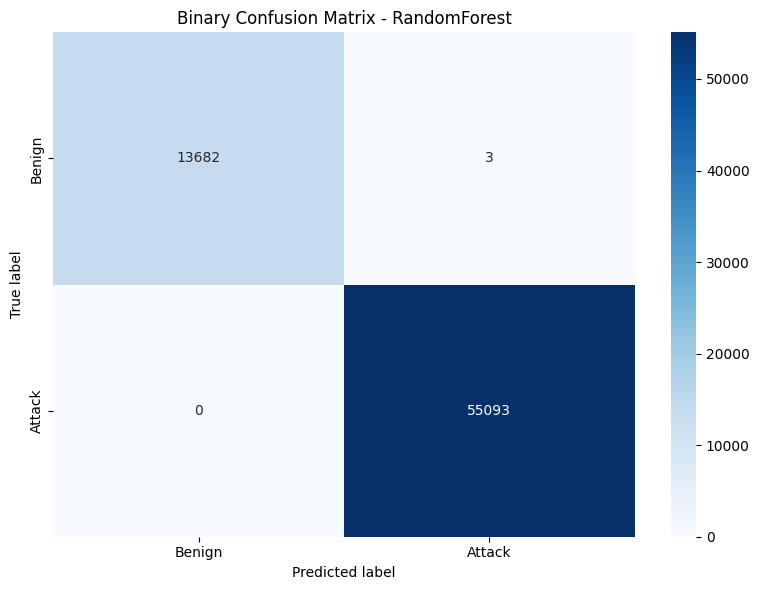

Plot saved: ./output/confusion_multiclass.png


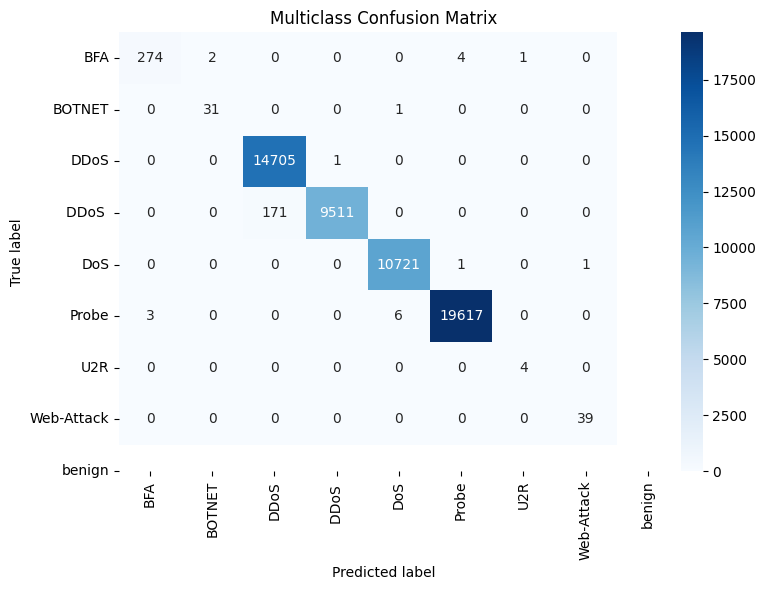


Pipeline finished successfully.


In [2]:
#!/usr/bin/env python3
"""
InSDN Dataset Analysis Pipeline - Jupyter Notebook version
Hardcoded paths:
    data_dir = "./data"
    output_dir = "./output"
The output directory is created automatically.
"""

import json
import os
import warnings
from typing import Any, Dict, List, Optional, Tuple, Union

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ========== Hardcoded paths ==========
DATA_DIR = "."          # folder containing Normal_data.csv, OVS.csv, metasploitable-2.csv
OUTPUT_DIR = "./output"      # where results will be stored


# ----------------------------------------------------------------------
# 1. Data loading
# ----------------------------------------------------------------------
def _find_target_column(df: pd.DataFrame, filename: str) -> pd.Series:
    """
    Locate the column containing the attack/benign label.
    Searches for 'type' (case-insensitive) first, then 'label'.
    If neither is found and the file is the normal traffic file,
    returns a Series filled with 'benign'.
    """
    cols_lower = {c.lower(): c for c in df.columns}
    for candidate in ("type", "label"):
        if candidate in cols_lower:
            return df[cols_lower[candidate]]
    if "normal" in filename.lower():
        return pd.Series("benign", index=df.index)
    raise KeyError(
        f"No 'type' or 'label' column found in {filename}. "
        "Expected one of them as target."
    )


def load_data(data_dir: str) -> pd.DataFrame:
    """
    Load all three CSVs, extract numerical features,
    add binary label (0=benign, 1=attack) and attack_type.
    """
    required_files = ["Normal_data.csv", "OVS.csv", "metasploitable-2.csv"]
    frames = []
    for fname in required_files:
        path = os.path.join(data_dir, fname)
        if not os.path.isfile(path):
            raise FileNotFoundError(f"Required file not found: {path}")
        df = pd.read_csv(path)
        target_series = _find_target_column(df, fname)
        is_benign = target_series.str.lower().isin(["normal", "benign"])
        df["label"] = 0
        df.loc[~is_benign, "label"] = 1
        df["attack_type"] = "benign"
        df.loc[df["label"] == 1, "attack_type"] = target_series[df["label"] == 1]
        feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        df_num = df[feature_cols].copy()
        df_num["label"] = df["label"]
        df_num["attack_type"] = df["attack_type"]
        frames.append(df_num)
    combined = pd.concat(frames, ignore_index=True)
    print(f"Total samples after loading: {len(combined)}")
    return combined


# ----------------------------------------------------------------------
# 2. Preprocessing
# ----------------------------------------------------------------------
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Handle missing values (median imputation) and remove constant features.
    """
    feature_df = df.drop(columns=["label", "attack_type"])
    labels = df[["label", "attack_type"]].copy()
    feature_df.fillna(feature_df.median(), inplace=True)
    constant_cols = feature_df.columns[feature_df.std() == 0]
    if len(constant_cols) > 0:
        print(f"Dropping {len(constant_cols)} constant features.")
        feature_df.drop(columns=constant_cols, inplace=True)
    out = feature_df.copy()
    out["label"] = labels["label"]
    out["attack_type"] = labels["attack_type"]
    return out


# ----------------------------------------------------------------------
# 3. Train / validation / test split
# ----------------------------------------------------------------------
def split_data(
    df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Stratified split by attack_type: 60% train, 20% validation, 20% test.
    """
    train_df, temp_df = train_test_split(
        df,
        test_size=0.4,
        stratify=df["attack_type"],
        random_state=RANDOM_STATE,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df["attack_type"],
        random_state=RANDOM_STATE,
    )
    print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
    return train_df, val_df, test_df


# ----------------------------------------------------------------------
# 4. Binary classification helpers
# ----------------------------------------------------------------------
def _build_binary_pipeline(model):
    """Wrap a classifier with a StandardScaler."""
    return Pipeline([("scaler", StandardScaler()), ("clf", model)])


def train_binary_models(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
) -> Dict[str, Any]:
    """
    Train three binary classifiers with hyper‑parameter tuning using the
    validation set as a single hold‑out fold via PredefinedSplit.
    Returns a dict mapping model name to best pipeline and final refitted pipeline.
    """
    # Combine train+val for the grid search split
    X_combined = pd.concat([X_train, X_val], ignore_index=True)
    y_combined = pd.concat([y_train, y_val], ignore_index=True)
    test_fold = np.concatenate([-np.ones(len(X_train)), np.zeros(len(X_val))])
    ps = PredefinedSplit(test_fold)

    # ----- Model definitions & small grids for speed on large data -----
    models_param_grid = {
        "LogisticRegression": (
            _build_binary_pipeline(
                LogisticRegression(
                    max_iter=500,          # reduced from 2000 – usually converges earlier
                    tol=1e-3,              # looser tolerance speeds up convergence
                    random_state=RANDOM_STATE,
                    solver="lbfgs",        # lbfgs is fast for L2 penalty on moderate feature counts
                    n_jobs=1,              # single thread for the model itself (grid search parallelism still used)
                )
            ),
            {
                "clf__C": [0.1, 1, 10],
                "clf__penalty": ["l2"],    # L2 only; lbfgs does not support L1
            },
        ),
        "RandomForest": (
            _build_binary_pipeline(
                RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
            ),
            {
                "clf__n_estimators": [100, 200],
                "clf__max_depth": [None, 10, 20],
            },
        ),
        "GradientBoosting": (
            _build_binary_pipeline(
                GradientBoostingClassifier(random_state=RANDOM_STATE)
            ),
            {
                "clf__n_estimators": [100, 200],
                "clf__learning_rate": [0.1, 0.05],
                "clf__max_depth": [3, 5],
            },
        ),
    }

    trained = {}
    for name, (pipe, param_grid) in models_param_grid.items():
        print(f"\nGrid search for {name} ...")
        grid = GridSearchCV(
            pipe,
            param_grid,
            cv=ps,
            scoring="f1",
            n_jobs=-1,           # parallelize across parameter combinations
            verbose=1,
        )
        grid.fit(X_combined, y_combined)
        trained[name] = {
            "pipeline": grid.best_estimator_,
            "best_params": grid.best_params_,
        }
        print(f"Best params {name}: {grid.best_params_}")

    # Refit final model on full train+validation
    X_train_val = pd.concat([X_train, X_val], ignore_index=True)
    y_train_val = pd.concat([y_train, y_val], ignore_index=True)
    for name in trained:
        best_cls = trained[name]["pipeline"].named_steps["clf"].__class__
        pipe = _build_binary_pipeline(
            best_cls(**trained[name]["pipeline"].named_steps["clf"].get_params())
        )
        pipe.set_params(**trained[name]["best_params"])
        pipe.fit(X_train_val, y_train_val)
        trained[name]["final_pipeline"] = pipe

    return trained


# ----------------------------------------------------------------------
# 5. Multiclass classification (attack type)
# ----------------------------------------------------------------------
def train_multiclass_model(
    X_train_val: pd.DataFrame,
    y_train_val: pd.Series,
    attack_type_train_val: pd.Series,
) -> Pipeline:
    """
    Train a RandomForest classifier to predict the attack type,
    using only attack samples (label == 1). Hyper‑parameters tuned
    with 3‑fold stratified cross‑validation.
    """
    mask = y_train_val == 1
    X_attack = X_train_val[mask]
    y_attack = attack_type_train_val[mask]
    print(f"Multiclass training samples: {len(X_attack)}")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    ])
    param_grid = {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 10, 20],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    grid = GridSearchCV(
        pipe, param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1, verbose=1
    )
    grid.fit(X_attack, y_attack)
    print(f"Multiclass best params: {grid.best_params_}")
    return grid.best_estimator_


# ----------------------------------------------------------------------
# 6. Evaluation
# ----------------------------------------------------------------------
def evaluate_binary(model: Pipeline, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    """Compute binary classification metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    }


def evaluate_multiclass(
    model: Pipeline,
    X_test: pd.DataFrame,
    y_test_binary: pd.Series,
    y_test_attack: pd.Series,
) -> dict:
    """Evaluate multiclass model on attack samples (normal traffic ignored)."""
    mask_attack = y_test_binary == 1
    y_true_attack = y_test_attack[mask_attack]
    X_attack_test = X_test[mask_attack]
    if len(X_attack_test) == 0:
        return {"classification_report": {}, "confusion_matrix": []}
    y_pred_attack = model.predict(X_attack_test)
    return {
        "classification_report": classification_report(
            y_true_attack, y_pred_attack, output_dict=True, zero_division=0
        ),
        "confusion_matrix": confusion_matrix(y_true_attack, y_pred_attack).tolist(),
    }


# ----------------------------------------------------------------------
# 7. Save results & plots
# ----------------------------------------------------------------------
def _plot_confusion_matrix(
    cm: Union[List[List[int]], np.ndarray],
    classes: List[str],
    title: str,
    save_path: Optional[str] = None,
):
    """Plot and save a confusion matrix heatmap."""
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes,
    )
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Plot saved: {save_path}")
    plt.show()
    plt.close()


def save_results(
    output_dir: str,
    test_df: pd.DataFrame,
    binary_preds: Dict[str, np.ndarray],
    binary_metrics: Dict[str, dict],
    multiclass_preds: np.ndarray,
    multiclass_metrics: dict,
    trained_models: Dict[str, Any],
    multiclass_model: Pipeline,
):
    """Save predictions CSV, metrics JSON, models, and confusion plots."""
    os.makedirs(output_dir, exist_ok=True)

    # ---- Predictions CSV ----
    pred_df = test_df[["label", "attack_type"]].copy()
    pred_df.rename(
        columns={"label": "true_binary_label", "attack_type": "true_attack_type"},
        inplace=True,
    )
    for name, preds in binary_preds.items():
        pred_df[f"pred_{name}"] = preds
    pred_df["pred_attack_type"] = multiclass_preds
    pred_csv = os.path.join(output_dir, "predictions.csv")
    pred_df.to_csv(pred_csv, index=False)
    print(f"Predictions saved to {pred_csv}")

    # ---- Metrics JSON ----
    def convert(o):
        if isinstance(o, (np.integer,)):
            return int(o)
        if isinstance(o, (np.floating,)):
            return float(o)
        if isinstance(o, np.ndarray):
            return o.tolist()
        return o

    metrics = {
        "binary": {name: {k: convert(v) for k, v in m.items()} for name, m in binary_metrics.items()},
        "multiclass": {k: convert(v) for k, v in multiclass_metrics.items()},
    }
    metrics_json = os.path.join(output_dir, "metrics.json")
    with open(metrics_json, "w") as f:
        json.dump(metrics, f, indent=2)
    print(f"Metrics saved to {metrics_json}")

    # ---- Models ----
    for name, info in trained_models.items():
        model_path = os.path.join(output_dir, f"binary_{name}.joblib")
        joblib.dump(info["final_pipeline"], model_path)
        print(f"Model saved: {model_path}")
    multiclass_path = os.path.join(output_dir, "multiclass_RF.joblib")
    joblib.dump(multiclass_model, multiclass_path)
    print(f"Model saved: {multiclass_path}")

    # ---- Plots ----
    best_binary = max(binary_metrics.items(), key=lambda x: x[1]["f1_score"])[0]
    _plot_confusion_matrix(
        binary_metrics[best_binary]["confusion_matrix"],
        classes=["Benign", "Attack"],
        title=f"Binary Confusion Matrix - {best_binary}",
        save_path=os.path.join(output_dir, "confusion_binary.png"),
    )
    if multiclass_metrics["confusion_matrix"]:
        _plot_confusion_matrix(
            multiclass_metrics["confusion_matrix"],
            classes=sorted(pred_df["true_attack_type"].unique()),
            title="Multiclass Confusion Matrix",
            save_path=os.path.join(output_dir, "confusion_multiclass.png"),
        )


# ----------------------------------------------------------------------
# 8. Execute pipeline in notebook
# ----------------------------------------------------------------------
print("Loading data...")
df = load_data(DATA_DIR)
print("Class distribution (binary):")
print(df["label"].value_counts())
print("\nAttack type distribution:")
print(df["attack_type"].value_counts())

print("\nPreprocessing...")
df = preprocess(df)

print("\nSplitting data...")
train_df, val_df, test_df = split_data(df)

X_train = train_df.drop(columns=["label", "attack_type"])
y_train = train_df["label"]
attack_type_train = train_df["attack_type"]

X_val = val_df.drop(columns=["label", "attack_type"])
y_val = val_df["label"]

X_test = test_df.drop(columns=["label", "attack_type"])
y_test = test_df["label"]
attack_type_test = test_df["attack_type"]

print("\nTraining binary classifiers...")
binary_info = train_binary_models(X_train, y_train, X_val, y_val)

print("\nTraining multiclass classifier...")
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)
attack_type_train_val = pd.concat(
    [attack_type_train, val_df["attack_type"]], ignore_index=True
)
multiclass_pipe = train_multiclass_model(
    X_train_val, y_train_val, attack_type_train_val
)

print("\nEvaluating on test set...")
binary_metrics = {}
binary_preds = {}
for name, info in binary_info.items():
    model = info["final_pipeline"]
    binary_metrics[name] = evaluate_binary(model, X_test, y_test)
    binary_preds[name] = model.predict(X_test)

multiclass_preds = np.array(["benign"] * len(X_test), dtype=object)
mask_test_attack = y_test == 1
if mask_test_attack.any():
    multiclass_preds[mask_test_attack] = multiclass_pipe.predict(
        X_test[mask_test_attack]
    )
multiclass_metrics = evaluate_multiclass(
    multiclass_pipe, X_test, y_test, attack_type_test
)

# Print summary with 6 decimal places
for name, m in binary_metrics.items():
    print(
        f"\n{name} -- Test accuracy: {m['accuracy']:.6f}, "
        f"F1: {m['f1_score']:.6f}, AUC: {m['roc_auc']:.6f}"
    )
if multiclass_metrics["classification_report"]:
    print("\nMulticlass classification report:")
    from pprint import pprint
    pprint(multiclass_metrics["classification_report"])

# Save everything
save_results(
    OUTPUT_DIR,
    test_df,
    binary_preds,
    binary_metrics,
    multiclass_preds,
    multiclass_metrics,
    binary_info,
    multiclass_pipe,
)

print("\nPipeline finished successfully.")